# Setup & Config

In [15]:
# 1. Imports & basic setup

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots show inside the notebook
%matplotlib inline

print(os.getcwd())

plt.style.use("seaborn-v0_8")

DATA_PATH = "../datasets/processed/final_combined.csv"


/mnt/partition1/machine_learning/phising_email_detection/notebooks


# Load a SAMPLE first (safe for RAM)

In [16]:
# 2. Load a SAMPLE of the dataset (e.g., 20k rows) for fast EDA

# How many rows to sample for quick analysis
SAMPLE_SIZE = 20000  

# Get total number of rows quickly (without loading whole CSV into RAM)
total_rows = sum(1 for _ in open(DATA_PATH, "r", encoding="utf-8")) - 1  # minus header
print(f"Total rows in file (approx): {total_rows}")

# Choose random row indices to keep
np.random.seed(42)
skip_rows = sorted(
    set(np.random.choice(np.arange(1, total_rows + 1), size=max(total_rows - SAMPLE_SIZE, 0), replace=False))
)

print(f"Skipping {len(skip_rows)} rows, loading ~{SAMPLE_SIZE} rows")

df = pd.read_csv(DATA_PATH, skiprows=skip_rows)
print("Shape of sample df:", df.shape)
df.head()

Total rows in file (approx): 3348324
Skipping 3328324 rows, loading ~20000 rows
Shape of sample df: (716, 19)


,id,subject,body_text,attachment_text,headers_raw,from_email,to_email,reply_to_email,date,urls,header_from_reply_mismatch,header_domain_mismatch,header_suspicious_tld,header_received_count,header_to_anomaly,header_x_mailer_anomaly,header_date_malformed,label,source
0,18d90bad-b40b-48db-a2bb-58751fd77a91,============== 15.88 ï¿½ï¿½ï¿½Ê¿ï¿½ ï¿½ï¿½ï¿½ï...,ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½...,NaN,NaN,djreort343gdr@daum.net,christie@groucho.cse.psu.edu,NaN,"Wed, 30 Jun 1993 13:15:49 +0300",NaN,0,0,0,0,0,0,0,1,TREC_06
1,6735ea0a-6576-49f3-b327-f86695f6211b,Re: your AMrBtEN,Hi\n \nL\nP\nA\nX\nV\nC\nV\ne\nr\nm\na\nI\nI\n...,NaN,NaN,ignaspe@cocacola-gh.com,mara@groucho.cse.psu.edu,NaN,"Tue, 26 Oct 1993 03:35:51 -0700",http://www.nitugoetes.com,0,0,0,0,0,0,0,1,TREC_06
2,917f5c20-134f-48ec-be07-87d65aa9ae76,plan 9 on sparc LX,Will Plan 9 run on the sparc LX? Our license ...,NaN,NaN,arnold@cc.gatech.edu,9fans@cse.psu.edu,NaN,"Mon, 06 Dec 1993 17:08:55 -0500",NaN,0,0,0,0,0,0,0,0,TREC_06
3,13859d70-276d-4a76-86f0-023fd76b693f,nofileserver.ms in postscript,Some people wanted the postscript version of n...,NaN,NaN,vijay@gl.umbc.edu,9fans@cse.psu.edu,NaN,"Thu, 03 Feb 1994 16:39:45 -0500",NaN,0,0,0,0,0,0,0,0,TREC_06
4,f7550cd2-ecfe-4677-9f46-f36a63fd6aad,Re: Gnots,>From the keyboard of Vijay Gill:\n\n> There w...,NaN,NaN,strat@ksu.ksu.edu,vijay@gl.umbc.edu,NaN,"Fri, 04 Feb 1994 11:50:54 -0500",NaN,0,0,0,0,0,0,0,0,TREC_06


# Quick schema & basic stats

In [17]:
print("Columns:\n", df.columns.tolist())

print("\nDataFrame info:")
print(df.info())

print("\nLabel value counts:")
print(df["label"].value_counts(dropna=False))

print("\nSources:")
print(df["source"].value_counts().head(10))

Columns:
 ['id', 'subject', 'body_text', 'attachment_text', 'headers_raw', 'from_email', 'to_email', 'reply_to_email', 'date', 'urls', 'header_from_reply_mismatch', 'header_domain_mismatch', 'header_suspicious_tld', 'header_received_count', 'header_to_anomaly', 'header_x_mailer_anomaly', 'header_date_malformed', 'label', 'source']

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716 entries, 0 to 715
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          716 non-null    object 
 1   subject                     711 non-null    object 
 2   body_text                   463 non-null    object 
 3   attachment_text             0 non-null      float64
 4   headers_raw                 257 non-null    object 
 5   from_email                  689 non-null    object 
 6   to_email                    684 non-null    object 
 7   reply_to_email             

# Add a few helper features (lengths, url counts)

In [18]:
# 4. Create helper features for analysis (doesn't modify your original CSV on disk)

df["subject"] = df["subject"].astype(str)
df["body_text"] = df["body_text"].astype(str)
df["urls"] = df["urls"].astype(str)

df["subject_len"] = df["subject"].str.len()
df["body_len"] = df["body_text"].str.len()
df["url_count"] = df["urls"].str.split().apply(len)  # number of URLs (space-separated)

df[["subject_len", "body_len", "url_count"]].describe()


,subject_len,body_len,url_count
count,716.000000,716.000000,716.000000
mean,35.893855,970.740223,1.365922
std,28.193337,1845.389940,1.620726
min,3.000000,3.000000,1.000000
25%,18.000000,3.000000,1.000000
50%,28.000000,496.000000,1.000000
75%,46.000000,1164.250000,1.000000
max,343.000000,21144.000000,24.000000


# Label distribution (ham vs phishing)

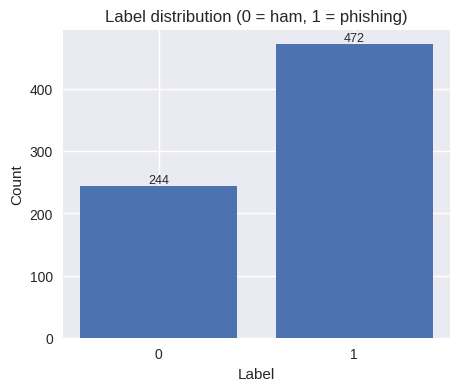

Label percentages (%):
label
0    34.08
1    65.92
Name: count, dtype: float64


In [19]:
# 5. Visualize label distribution

label_counts = df["label"].value_counts().sort_index()
plt.figure(figsize=(5,4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Label distribution (0 = ham, 1 = phishing)")
plt.xlabel("Label")
plt.ylabel("Count")
for i, v in enumerate(label_counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
plt.show()

# Also print percentages
print("Label percentages (%):")
print((label_counts / label_counts.sum() * 100).round(2))


# Source-wise row counts

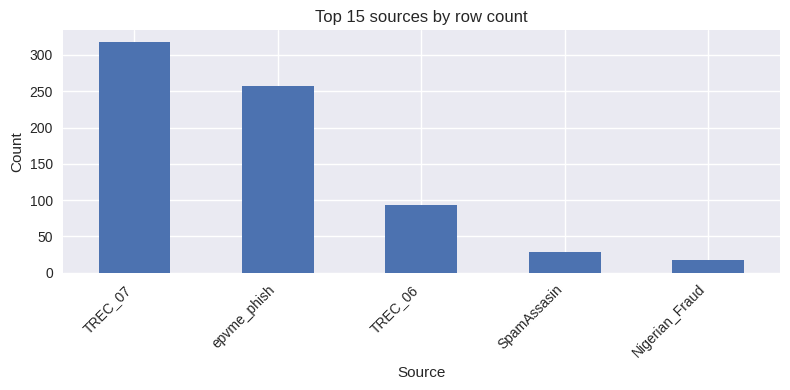

source
TREC_07           318
epvme_phish       257
TREC_06            94
SpamAssasin        29
Nigerian_Fraud     18
Name: count, dtype: int64

In [20]:
# 6. Top sources by row count

source_counts = df["source"].value_counts()
plt.figure(figsize=(8,4))
source_counts.head(15).plot(kind="bar")
plt.title("Top 15 sources by row count")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

source_counts.head(15)


# Text length distribution

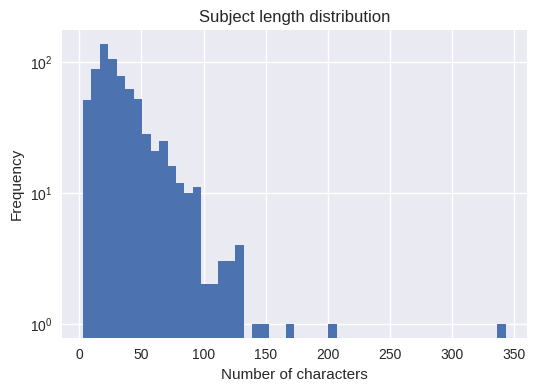

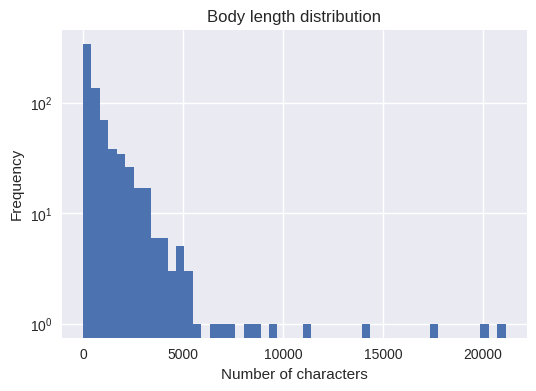

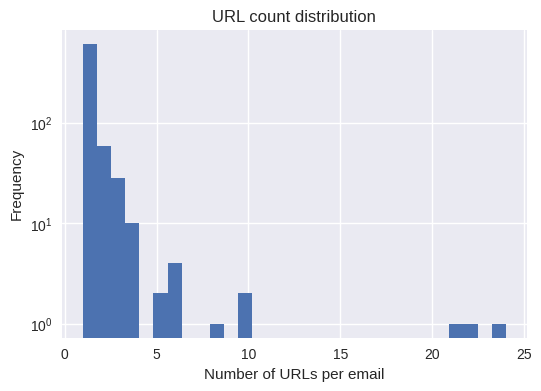

In [21]:
# 7. Subject / body length distributions (log-scale to see tail better)

plt.figure(figsize=(6,4))
plt.hist(df["subject_len"], bins=50)
plt.title("Subject length distribution")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["body_len"], bins=50)
plt.title("Body length distribution")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["url_count"], bins=30)
plt.title("URL count distribution")
plt.xlabel("Number of URLs per email")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()

# Identify the anomaly-feature columns

In [22]:
# 8. Identify header anomaly feature columns

header_cols = [c for c in df.columns if c.startswith("header_")]
header_cols

['header_from_reply_mismatch',
 'header_domain_mismatch',
 'header_suspicious_tld',
 'header_received_count',
 'header_to_anomaly',
 'header_x_mailer_anomaly',
 'header_date_malformed']

# Visualize anomaly feature prevalence

Binary anomaly features: ['header_from_reply_mismatch', 'header_domain_mismatch', 'header_suspicious_tld', 'header_received_count', 'header_to_anomaly', 'header_x_mailer_anomaly', 'header_date_malformed']
Numeric anomaly features: []


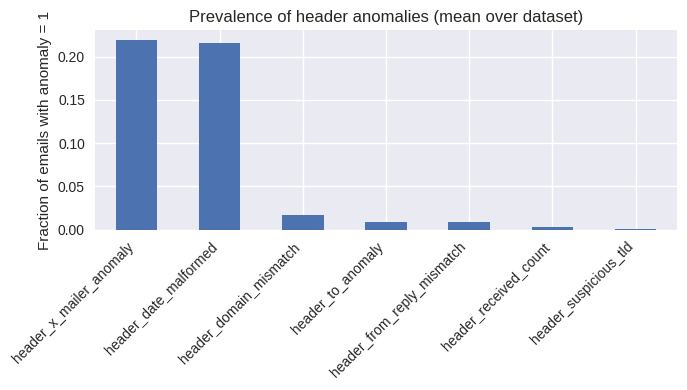

In [23]:
# 9. Visualize prevalence of header anomaly features

# Separate binary anomaly features (0/1) from numeric ones
binary_anoms = []
numeric_anoms = []

for c in header_cols:
    unique_vals = df[c].dropna().unique()
    if set(unique_vals).issubset({0, 1}):
        binary_anoms.append(c)
    else:
        numeric_anoms.append(c)

print("Binary anomaly features:", binary_anoms)
print("Numeric anomaly features:", numeric_anoms)

# Prevalence of binary anomalies
if binary_anoms:
    prevalence = df[binary_anoms].mean().sort_values(ascending=False)
    plt.figure(figsize=(7,4))
    prevalence.plot(kind="bar")
    plt.title("Prevalence of header anomalies (mean over dataset)")
    plt.ylabel("Fraction of emails with anomaly = 1")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No binary anomaly features detected.")


# Compare anomaly prevalence by label (ham vs phishing)

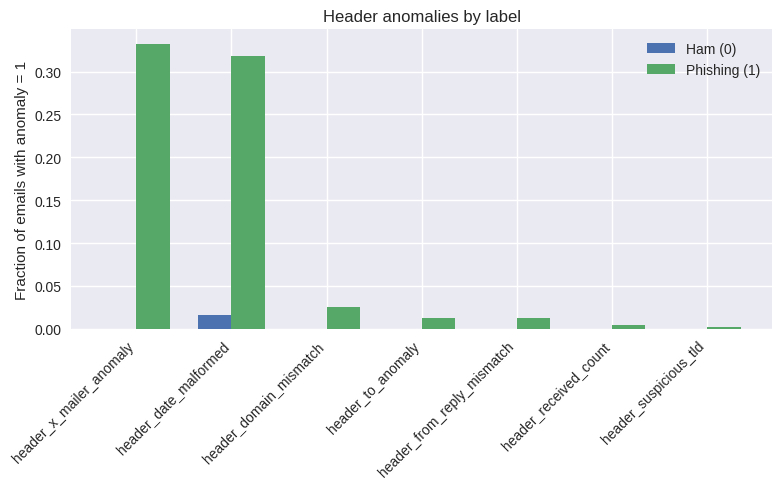

In [24]:
# 10. Compare binary header anomalies between ham (0) and phishing (1)

if binary_anoms:
    grouped_means = df.groupby("label")[binary_anoms].mean().T  # rows = features, cols = labels
    grouped_means = grouped_means.sort_values(by=1, ascending=False)  # sort by phishing prevalence

    plt.figure(figsize=(8,5))
    x = np.arange(len(grouped_means.index))
    width = 0.35

    plt.bar(x - width/2, grouped_means[0], width, label="Ham (0)")
    plt.bar(x + width/2, grouped_means[1], width, label="Phishing (1)")

    plt.xticks(x, grouped_means.index, rotation=45, ha="right")
    plt.ylabel("Fraction of emails with anomaly = 1")
    plt.title("Header anomalies by label")
    plt.legend()
    plt.tight_layout()
    plt.show()

    grouped_means
else:
    print("No binary anomalies to compare.")


# Distribution of `header_received_count`

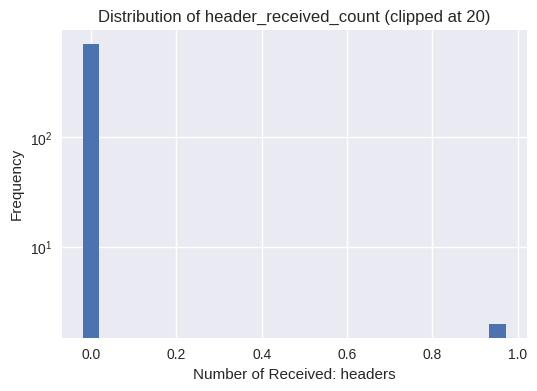

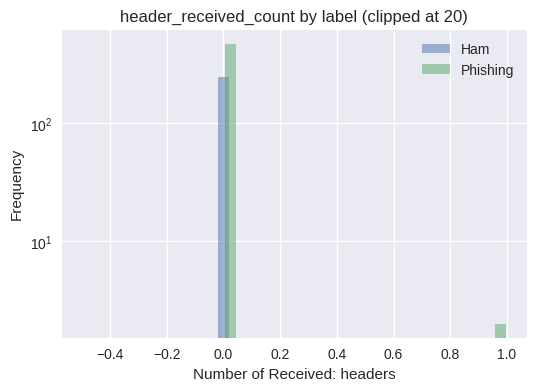

In [25]:
# 11. Distribution of header_received_count

if "header_received_count" in df.columns:
    # Clip to avoid very long tail in visualization
    clipped = df["header_received_count"].clip(lower=0, upper=20)

    plt.figure(figsize=(6,4))
    plt.hist(clipped, bins=21, align="left", rwidth=0.8)
    plt.title("Distribution of header_received_count (clipped at 20)")
    plt.xlabel("Number of Received: headers")
    plt.ylabel("Frequency")
    plt.yscale("log")
    plt.show()

    # Optional: compare by label
    plt.figure(figsize=(6,4))
    for label_value, label_name in [(0, "Ham"), (1, "Phishing")]:
        subset = df[df["label"] == label_value]["header_received_count"].clip(0, 20)
        plt.hist(subset, bins=21, alpha=0.5, label=label_name, rwidth=0.8)

    plt.title("header_received_count by label (clipped at 20)")
    plt.xlabel("Number of Received: headers")
    plt.ylabel("Frequency")
    plt.yscale("log")
    plt.legend()
    plt.show()
else:
    print("Column header_received_count not found.")


# Correlation between anomalies & label

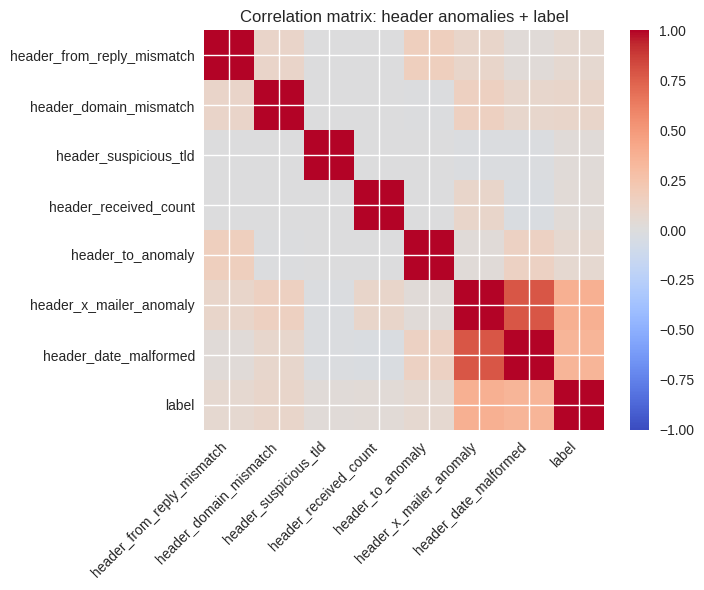

label                         1.000000
header_x_mailer_anomaly       0.381038
header_date_malformed         0.347684
header_domain_mismatch        0.093870
header_to_anomaly             0.066095
header_from_reply_mismatch    0.066095
header_received_count         0.038053
header_suspicious_tld         0.026889
Name: label, dtype: float64

In [26]:
# 12. Correlation matrix for anomaly features + label

cols_for_corr = header_cols + ["label"]
corr_df = df[cols_for_corr].corr()

plt.figure(figsize=(8,6))
im = plt.imshow(corr_df, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(cols_for_corr)), cols_for_corr, rotation=45, ha="right")
plt.yticks(range(len(cols_for_corr)), cols_for_corr)
plt.title("Correlation matrix: header anomalies + label")
plt.tight_layout()
plt.show()

corr_df["label"].sort_values(ascending=False)